## <center> Prelims 2023
### <center> Mani Tyagi
#### <center> 200973108

In [51]:
# importing libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad


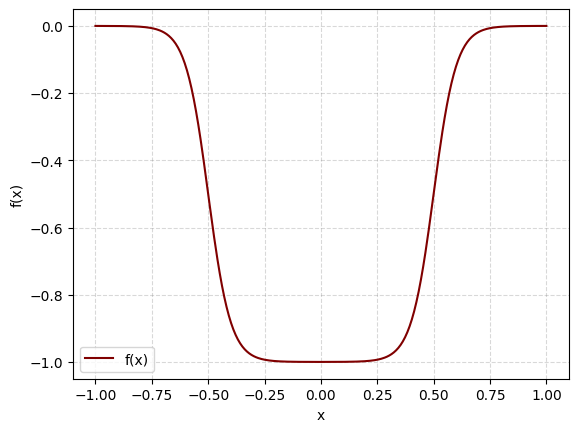

In [52]:
def f(x):
    return (np.tanh(10*x - 5) - np.tanh(10*x+5))/2

# plotting the function
x = np.linspace(-1,1,400)
plt.plot(x, f(x),color='maroon',label='f(x)')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True,linestyle='dashed',alpha=0.3,color='gray')
plt.legend()
plt.show()

### Part (a)

In [53]:
def legendre_polynomial(n, x):
    if n == 0:
        return 1
    elif n == 1:
        return x
    elif n == 2:
        return 0.5 * (3*x**2 - 1)
    elif n == 3:
        return 0.5 * (5*x**3 - 3*x)
    elif n == 4:
        return (1/8.0) * (35*x**4 - 30*x**2 + 3)
    else:
        raise ValueError("Only n = 0, 1, 2, 3, 4 are supported")

# function to calculate coefficients
def coefficients(n, x, f):
    # Define the integrand as a function of x
    def integrand(x):
        return f(x) * legendre_polynomial(n, x)
    
    # Perform the integration over the interval [-1, 1]
    I, _ = quad(integrand, -1, 1)
    
    return ((2*n+1)/2.0) * I
    
# function to print the coefficients    
def print_coefficients(max_n, f):
    for n in range(max_n+1):
        c = coefficients(n, x, f)
        print(f"Coefficient c{n}: {c}")
        
print_coefficients(4, f)        

Coefficient c0: -0.4999977300550438
Coefficient c1: 0.0
Coefficient c2: 0.9066706235738025
Coefficient c3: 0.0
Coefficient c4: -0.4750742250806061


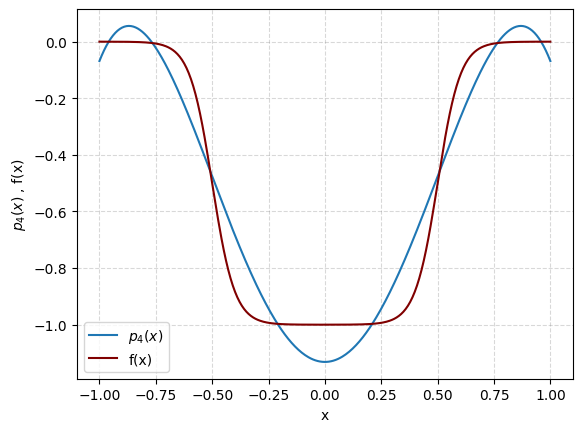

In [54]:
def construct_Pn(n, f):
    # Compute the coefficients c_i for i in range(n+1)
    coeffs = [coefficients(i, x, f) for i in range(n+1)]
    
    # Define the polynomial function Pn(x)
    def Pn(x):
        return sum(c * legendre_polynomial(i, x) for i, c in enumerate(coeffs))
    
    return Pn

# Construct P4(x) for the example function
Pn_function = construct_Pn(4, f)

# Generate x values and compute P4(x) values
x_values = np.linspace(-1, 1, 400)
Pn_values = [Pn_function(x) for x in x_values]

# Plot P4(x)
plt.plot(x_values, Pn_values, label="$p_4(x)$")
plt.plot(x, f(x),color='maroon',label='f(x)')
plt.xlabel('x')
plt.ylabel('$p_4(x)$ , f(x)')
plt.xlabel('x')
plt.legend()
plt.grid(True,linestyle='dashed',alpha=0.3,color='gray')
plt.show()

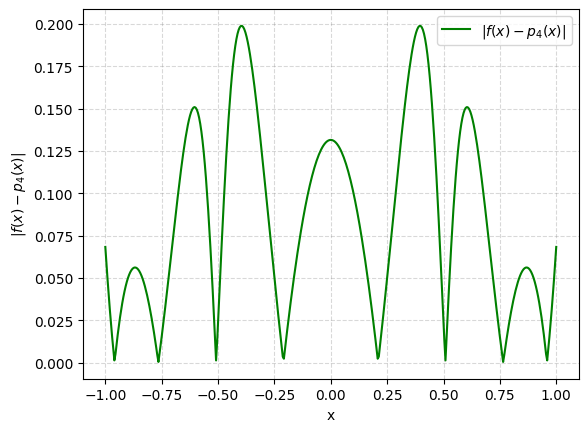

In [55]:

plt.plot(x, abs(f(x)-Pn_values),color='green',label='$|f(x)-p_4(x)|$')
plt.xlabel('x')
plt.ylabel('$|f(x)-p_4(x)|$')
plt.xlabel('x')
plt.legend()
plt.grid(True,linestyle='dashed',alpha=0.3,color='gray')
plt.show()